In [ ]:
#### Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [ ]:
#### Load Dataset

In [2]:
df = pd.read_csv("AmesHousing.csv")

In [ ]:
##### Display First 5 Rows

In [3]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
df.tail()

In [ ]:
#### Check Dataset Shape

In [5]:
df.shape

(2930, 82)

In [ ]:
#### Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [ ]:
#### Check Data Types

In [10]:
df.dtypes

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning          object
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type          object
Sale Condition     object
SalePrice           int64
Length: 82, dtype: object

In [ ]:
#### Check Missing Values

In [11]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [ ]:
#### Check Duplicate Records

In [13]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#### Descriptive Statistics

In [14]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [15]:
# Numerical Columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical Columns
cat_cols = df.select_dtypes(include=["object"]).columns

df[cat_cols] = df[cat_cols].fillna("Unknown")

In [ ]:
#### Check Missing Values Again

In [17]:
df.isnull().sum()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 82, dtype: int64

In [ ]:
#### Feature Selection

In [19]:
target = "SalePrice"

X = df.drop(columns=[target])

y = df[target]

In [ ]:
#### Identify Categorical and Numerical Columns

In [21]:
categorical_cols = X.select_dtypes(include=["object"]).columns

numerical_cols = X.select_dtypes(exclude=["object"]).columns

In [ ]:
#### One-Hot Encoding

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

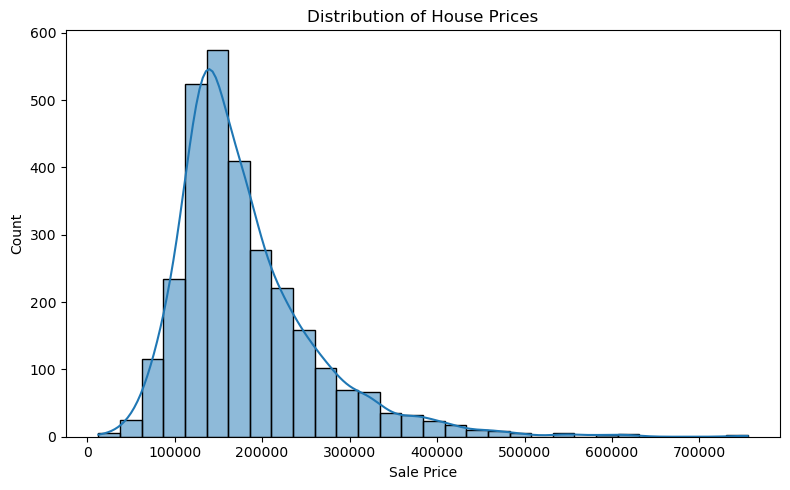

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
## Observation
-- Most house prices are concentrated in the lower to middle price range.
-- A few houses have very high prices.

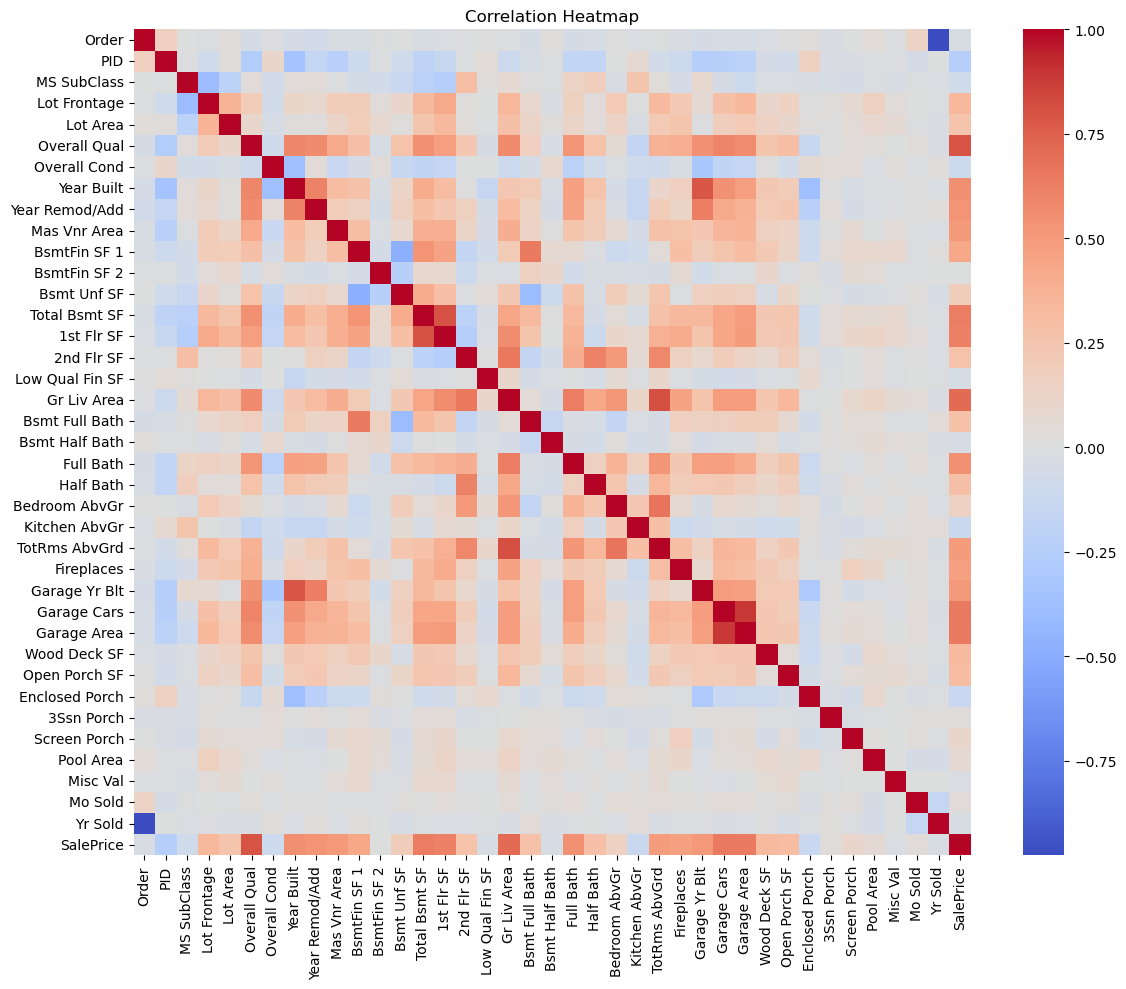

In [27]:
plt.figure(figsize=(12,10))

correlation = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(correlation, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#### Top Features Correlated with Sale Price

In [28]:
correlation["SalePrice"].sort_values(ascending=False)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647812
Garage Area        0.640381
Total Bsmt SF      0.632164
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.508882
Mas Vnr Area       0.502196
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432862
Lot Frontage       0.340256
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.275823
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182895
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.006018
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035817
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

In [ ]:
#### Train-Test Split (80/20

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (2344, 81)
Testing Features  : (586, 81)
Training Target   : (2344,)
Testing Target    : (586,)


In [ ]:
### Observation
##### The dataset has been split into 80% training data and 20% testing data.
##### The training set will be used to build the Linear Regression model,
###### while the testing set will be used to evaluate its performance.

In [ ]:
#### Train Linear Regression Model

In [32]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
#### Predict House Prices

In [34]:
y_pred = model.predict(X_test)

In [ ]:
#### Calculate Mean Squared Error (MSE)

In [35]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", round(mse, 2))

Mean Squared Error (MSE): 2112274136.29


In [ ]:
#### Calculate Root Mean Squared Error (RMSE)

In [36]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", round(rmse, 2))

Root Mean Squared Error (RMSE): 45959.48


In [ ]:
#### Calculate R² Score

In [37]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", round(r2, 4))

R² Score: 0.7365


In [ ]:
#### Model Performance

In [38]:
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MSE  : 2112274136.29
RMSE : 45959.48
R²   : 0.7365


In [ ]:
#### Observation
###### Lower MSE and RMSE indicate better prediction accuracy.
###### An R² Score closer to 1 indicates better model performance.

In [ ]:
#### Actual vs Predicted Prices

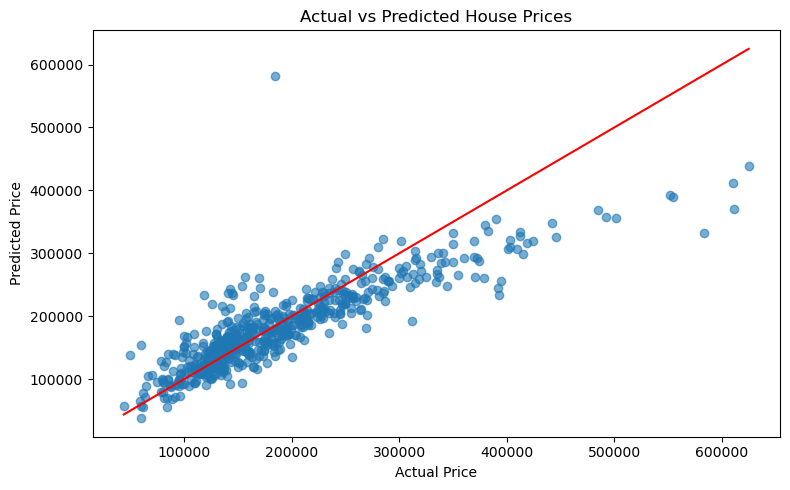

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#### Residual Plot

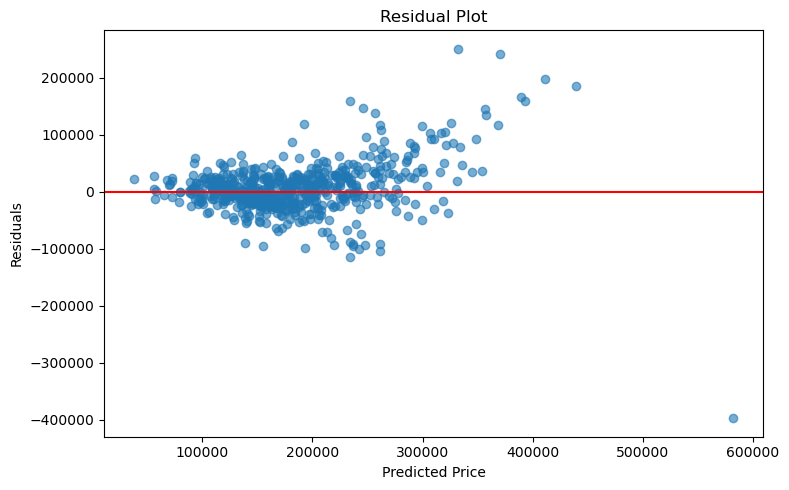

In [41]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color="red")

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.tight_layout()
plt.savefig("residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#### Coefficient Analysis

In [42]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

coefficients = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
296,remainder__Gr Liv Area,52.813924
292,remainder__Total Bsmt SF,37.793979
293,remainder__1st Flr SF,32.638037
289,remainder__BsmtFin SF 1,27.320235
294,remainder__2nd Flr SF,20.245886
307,remainder__Garage Area,19.414870
288,remainder__Mas Vnr Area,11.857747
291,remainder__Bsmt Unf SF,10.517829
308,remainder__Wood Deck SF,6.030017
309,remainder__Open Porch SF,3.066647


In [ ]:
#### Top Positive Features

In [44]:
coef_df.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
296,remainder__Gr Liv Area,52.813924
292,remainder__Total Bsmt SF,37.793979
293,remainder__1st Flr SF,32.638037
289,remainder__BsmtFin SF 1,27.320235
294,remainder__2nd Flr SF,20.245886
307,remainder__Garage Area,19.414870
288,remainder__Mas Vnr Area,11.857747
291,remainder__Bsmt Unf SF,10.517829
308,remainder__Wood Deck SF,6.030017
309,remainder__Open Porch SF,3.066647


In [ ]:
#### Top Negative Features

In [45]:
coef_df.sort_values(by="Coefficient").head(10)

,Feature,Coefficient
314,remainder__Misc Val,-4.404531
310,remainder__Enclosed Porch,-1.130707
281,remainder__MS SubClass,-0.107440
295,remainder__Low Qual Fin SF,-0.069999
143,cat__Exter Qual_TA,-0.045034
207,cat__Kitchen Qual_TA,-0.041852
159,cat__Bsmt Qual_TA,-0.035701
221,cat__Fireplace Qu_Unknown,-0.033807
290,remainder__BsmtFin SF 2,-0.033686
150,cat__Foundation_CBlock,-0.032045


## Conclusion
##### A Linear Regression model was built to predict house prices.
##### Missing values were handled and categorical features were encoded using One-Hot Encoding.
##### The dataset was split into training and testing sets.
##### The model was evaluated using MSE, RMSE, and R² Score.
##### The prediction results show how well the model estimates house prices.
##### Feature coefficients helped identify which variables have the greatest impact on house prices